## Importing Package and Reading Data

In [3]:
import pandas as pd 
path =r"C:\Users\Lenovo\Downloads\collegePlace.csv"
df=pd.read_csv(path)
df.head()

,Age,Gender,Stream,Internships,CGPA,Hostel,HistoryOfBacklogs,PlacedOrNot
0,22,Male,Electronics And Communication,1,8,1,1,1
1,21,Female,Computer Science,0,7,1,1,1
2,22,Female,Information Technology,1,6,0,0,1
3,21,Male,Information Technology,0,8,0,1,1
4,22,Male,Mechanical,0,8,1,0,1


In [4]:
df.shape

(2966, 8)

In [5]:
df['Gender'].replace({'Male':0,'Female':1},inplace=True)

C:\Users\Lenovo\AppData\Local\Temp\ipykernel_14940\4071885255.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Gender'].replace({'Male':0,'Female':1},inplace=True)
C:\Users\Lenovo\AppData\Local\Temp\ipykernel_14940\4071885255.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['Gender'].re

In [6]:
df.head()

,Age,Gender,Stream,Internships,CGPA,Hostel,HistoryOfBacklogs,PlacedOrNot
0,22,0,Electronics And Communication,1,8,1,1,1
1,21,1,Computer Science,0,7,1,1,1
2,22,1,Information Technology,1,6,0,0,1
3,21,0,Information Technology,0,8,0,1,1
4,22,0,Mechanical,0,8,1,0,1


In [7]:
df['Stream'].unique()

array(['Electronics And Communication', 'Computer Science',
       'Information Technology', 'Mechanical', 'Electrical', 'Civil'],
      dtype=object)

## Cleaning of Data

In [8]:
df['Stream'] = df['Stream'].replace({
    'Electronics And Communication': 0,
    'Computer Science': 1,
    'Information Technology': 2,
    'Mechanical': 3,
    'Electrical': 4,
    'Civil': 5
})


C:\Users\Lenovo\AppData\Local\Temp\ipykernel_14940\158507651.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['Stream'] = df['Stream'].replace({


In [9]:
df.head()

,Age,Gender,Stream,Internships,CGPA,Hostel,HistoryOfBacklogs,PlacedOrNot
0,22,0,0,1,8,1,1,1
1,21,1,1,0,7,1,1,1
2,22,1,2,1,6,0,0,1
3,21,0,2,0,8,0,1,1
4,22,0,3,0,8,1,0,1


In [10]:
# print(X_train.dtypes)
print(df['Stream'].dtype)



int64


In [11]:
df.isnull().sum()

Age                  0
Gender               0
Stream               0
Internships          0
CGPA                 0
Hostel               0
HistoryOfBacklogs    0
PlacedOrNot          0
dtype: int64

## Importing Matplotlib

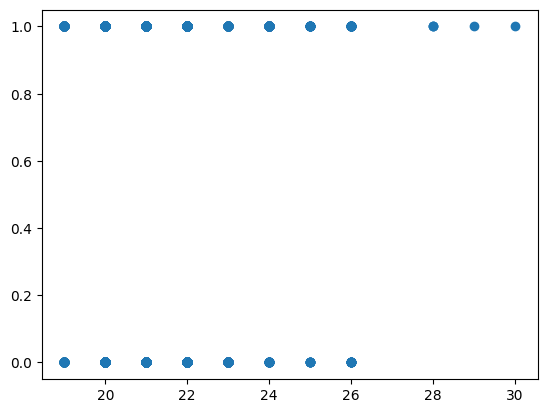

In [12]:
import matplotlib.pyplot as plt
age=df['Age']
stream=df['Stream']
internships=df['Internships']
cgpa=df['CGPA']
hostel=df['Hostel']
backlogs=df['HistoryOfBacklogs']
y=df['PlacedOrNot']
plt.scatter(age,y)

## Removed column "Placed or Not"

In [13]:
y=df['PlacedOrNot']
X=df.drop(['PlacedOrNot'],axis=1)

In [14]:
X

,Age,Gender,Stream,Internships,CGPA,Hostel,HistoryOfBacklogs
0,22,0,0,1,8,1,1
1,21,1,1,0,7,1,1
2,22,1,2,1,6,0,0
3,21,0,2,0,8,0,1
4,22,0,3,0,8,1,0
...,...,...,...,...,...,...,...
2961,23,0,2,0,7,0,0
2962,23,0,3,1,7,1,0
2963,22,0,2,1,7,0,0
2964,22,0,1,1,7,0,0


## Applying Logistic Regression

In [15]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(X,y,train_size=0.8,random_state=1)

In [16]:
from sklearn.linear_model import LogisticRegression
from sklearn import metrics

In [17]:
logreg=LogisticRegression()

In [18]:
print(X_train)

      Age  Gender  Stream  Internships  CGPA  Hostel  HistoryOfBacklogs
557    21       1       5            1     7       0                  1
1039   22       1       2            1     8       0                  0
561    21       0       1            1     7       0                  0
2819   22       0       3            0     6       1                  0
2039   20       0       1            2     7       0                  0
...   ...     ...     ...          ...   ...     ...                ...
2763   21       1       1            1     8       1                  0
905    22       0       4            0     8       0                  1
1096   22       0       0            1     7       0                  1
235    22       0       1            1     8       0                  0
1061   22       0       1            1     7       0                  0

[2372 rows x 7 columns]


## Predicting Output and its Accuracy through Confusion Matrix

In [19]:
logreg = LogisticRegression(max_iter=1000)

In [20]:
logreg.fit(X_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [21]:
y_pred=logreg.predict(X_test)

In [22]:
print(y_pred)

[0 1 0 0 1 1 1 0 0 1 1 1 1 1 1 1 1 0 1 1 1 1 0 1 0 1 1 1 1 1 1 0 0 1 1 0 0
 0 0 1 0 1 1 0 0 1 0 1 1 1 1 1 0 0 0 1 1 1 1 1 1 1 1 0 0 0 1 1 1 1 1 1 1 1
 1 1 0 1 0 1 1 1 1 0 1 0 0 1 1 1 1 0 1 1 1 1 0 1 1 1 1 1 0 1 1 1 0 0 1 0 1
 0 0 0 0 0 1 0 0 1 0 1 0 1 0 0 1 0 1 0 0 1 1 0 1 1 0 0 1 0 1 0 0 1 0 1 1 1
 1 0 0 1 1 1 1 0 1 1 0 0 1 1 0 1 0 1 1 1 0 0 0 0 1 1 1 0 0 0 1 0 1 1 1 0 1
 1 0 0 1 0 1 0 1 0 0 0 0 1 1 0 1 0 1 1 1 1 1 0 0 0 0 1 1 1 1 1 0 1 1 1 0 1
 0 0 1 1 0 0 1 1 1 0 0 0 1 1 1 0 1 0 1 1 1 1 1 0 1 0 1 1 0 1 0 1 1 0 0 0 1
 1 0 0 0 0 0 1 0 1 0 0 1 0 0 1 1 1 1 1 0 0 1 1 0 1 0 1 1 1 1 0 0 0 0 1 1 0
 0 0 1 0 1 1 0 1 1 0 1 1 0 1 1 1 0 1 0 0 1 1 0 1 1 0 1 0 1 0 1 1 0 0 1 0 0
 1 1 0 1 1 0 1 1 0 0 0 1 0 1 1 1 0 1 0 1 0 0 0 0 1 0 1 1 1 1 1 1 0 1 1 1 1
 0 0 1 1 0 0 1 1 1 1 1 1 1 0 1 1 1 0 1 1 1 1 0 1 1 1 0 0 1 1 1 1 1 1 0 1 1
 1 1 1 1 1 1 1 0 1 0 0 0 1 0 0 1 0 0 1 0 0 0 1 0 1 0 0 0 1 1 1 0 0 1 0 1 0
 1 0 0 1 0 0 1 1 0 1 1 1 0 0 0 0 1 0 0 1 1 1 1 1 1 0 1 1 0 0 1 1 1 0 1 1 1
 1 1 0 1 0 0 1 1 0 0 0 0 

In [23]:
print(logreg.score(X_test,y_test))

0.7693602693602694


In [24]:
logreg.predict([[0,2,8,90,85,0,1]])

C:\Users\Lenovo\AppData\Roaming\Python\Python313\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


array([1])

In [25]:
from sklearn.metrics import confusion_matrix,accuracy_score,classification_report
import seaborn as sns

In [26]:
print(confusion_matrix(y_test,y_pred))
print(accuracy_score(y_test,y_pred))

[[189  74]
 [ 63 268]]
0.7693602693602694


In [27]:
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.75      0.72      0.73       263
           1       0.78      0.81      0.80       331

    accuracy                           0.77       594
   macro avg       0.77      0.76      0.77       594
weighted avg       0.77      0.77      0.77       594



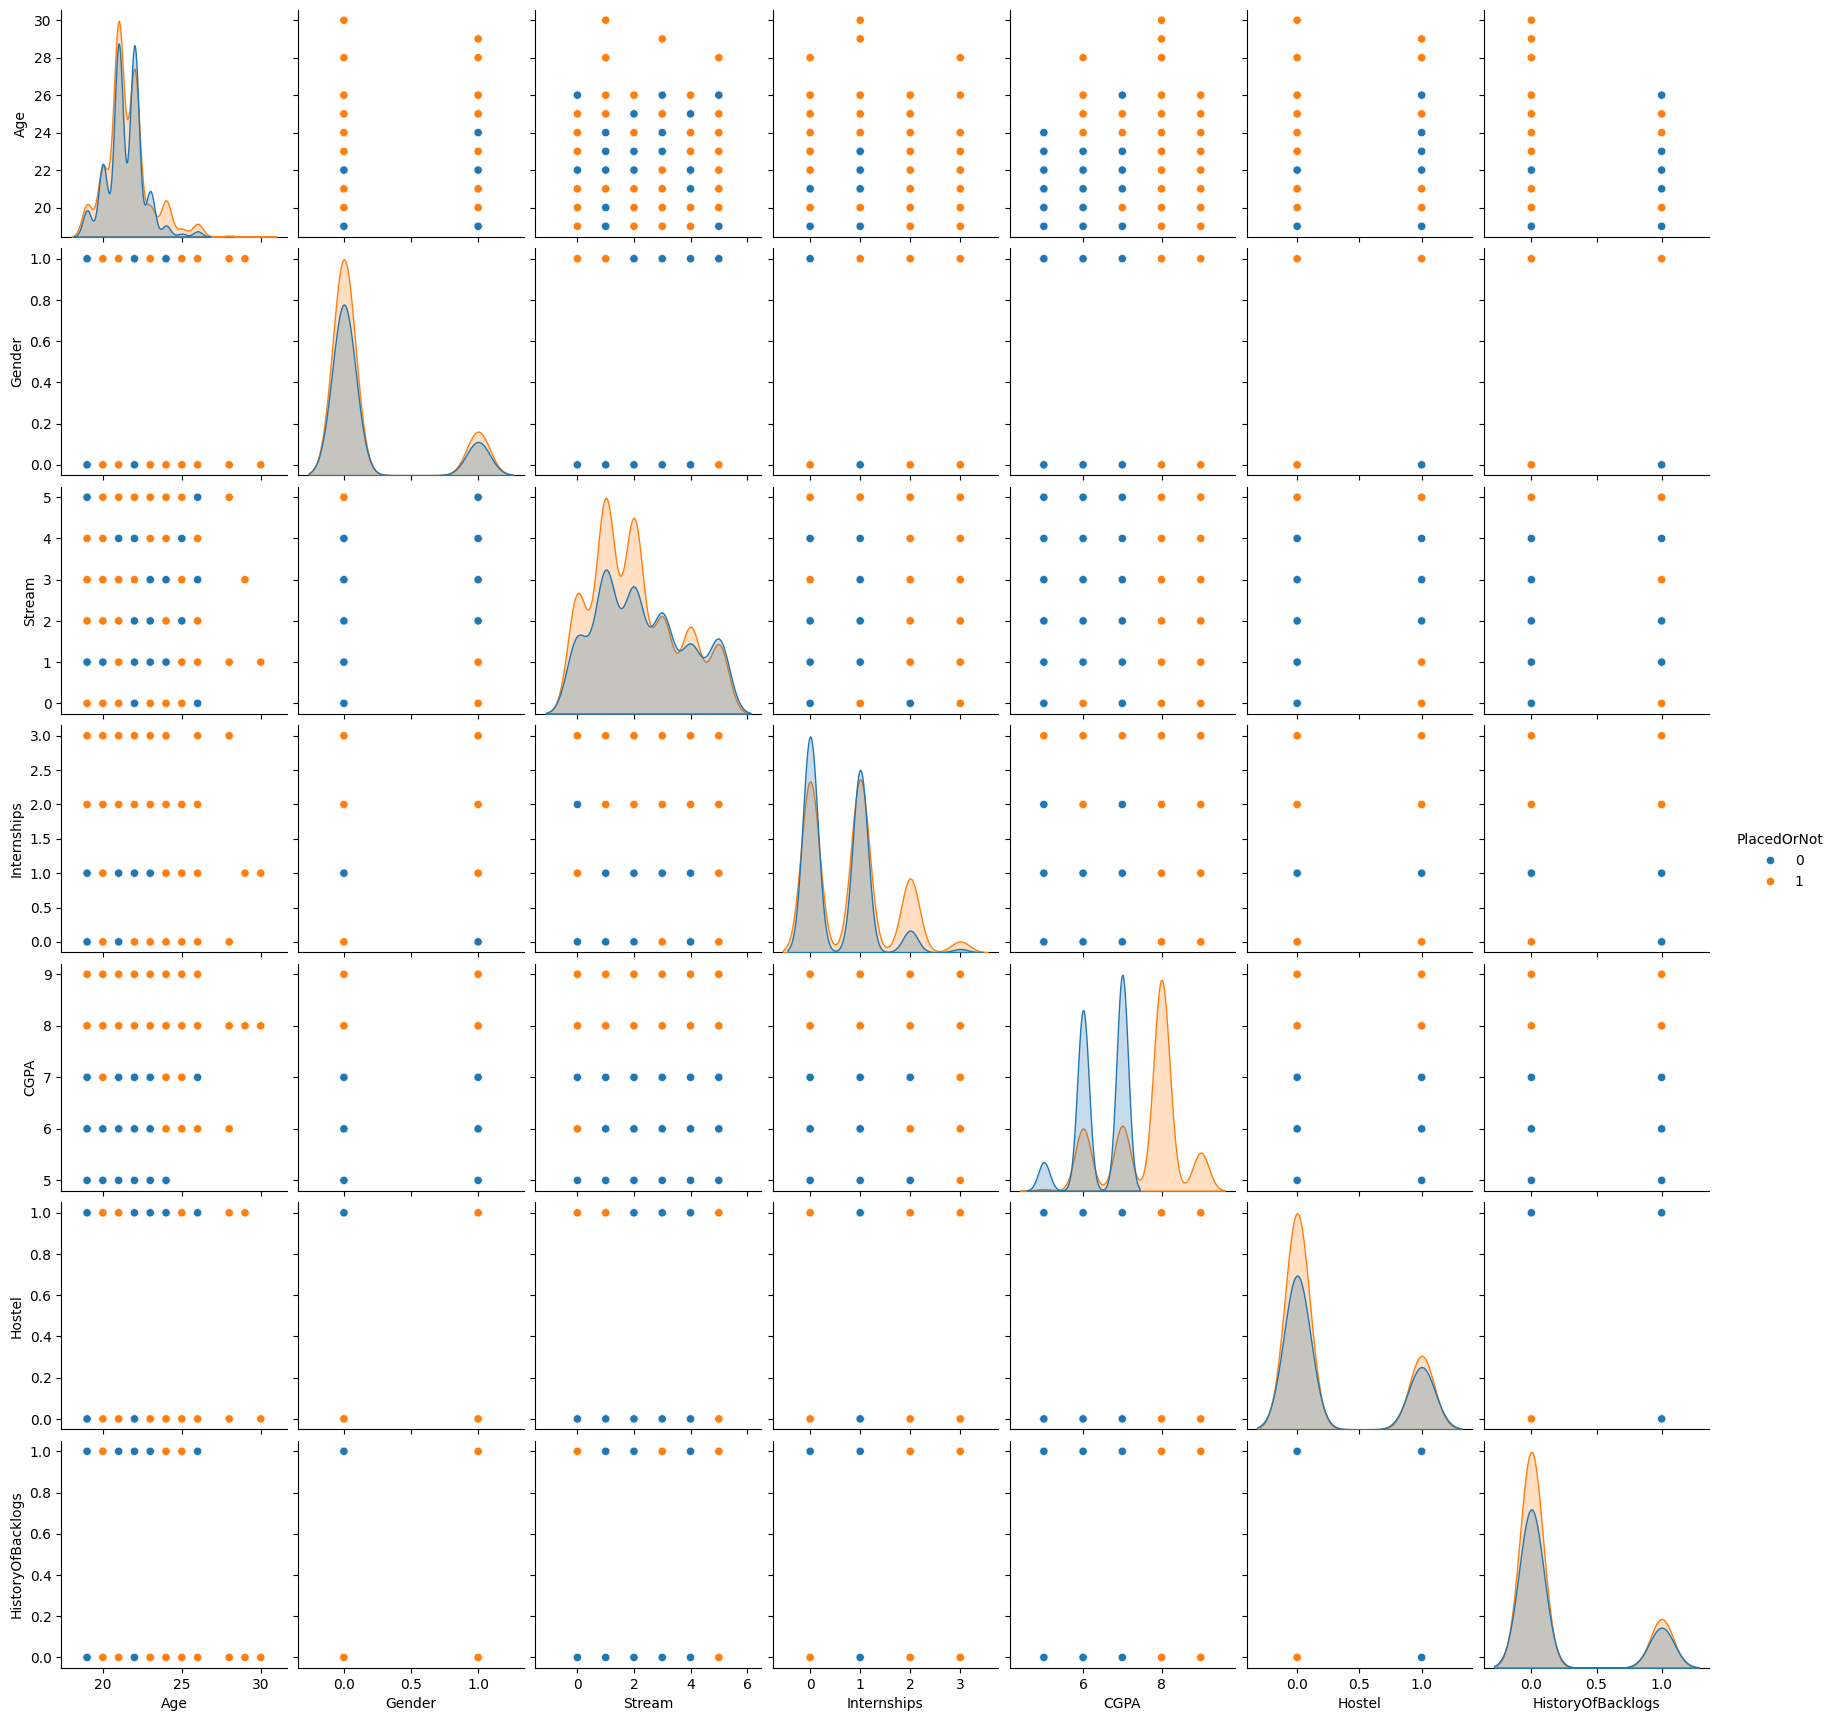

In [28]:
sns.pairplot(df,hue='PlacedOrNot')

In [29]:
import pickle 
pickle.dump(logreg,open("model.pkl","wb"))

In [ ]:
acc = accuracy_score(y_test, y_pred)
pickle.dump(acc, open("accuracy.pkl", "wb"))


In [31]:

cm = confusion_matrix(y_test, y_pred)

pickle.dump(cm, open("cm.pkl", "wb"))